# Baseline Model Training on SECOM

**Project:** AIoT Predictive Maintenance for Semiconductor Test Equipment  
**Module:** LD7182 — AI for IoT  
**Author:** Rekhanth Reddy Obireddy  
**Date:** 30 April 2026

## Goal
Train and evaluate three baseline classifiers on the preprocessed SECOM
dataset to establish a performance benchmark for the TinyML model.

## Models
1. **Random Forest** — robust to imbalance, baseline ensemble method
2. **XGBoost** — current SOTA for tabular data
3. **Multi-Layer Perceptron (MLP)** — neural network baseline (sklearn)

## Evaluation Metrics
Given SECOM's 6.6% class imbalance, accuracy is misleading. Primary
metrics are:
- **F1-score (minority class)** — primary metric
- **Recall (minority class)** — catching real failures
- **Precision (minority class)** — avoiding false alarms
- **AUC-ROC** — overall ranking quality
- **Confusion matrix** — breakdown of errors

## Reference Performance Benchmarks (from literature)
- Salem & Bhuiyan (2025): SVC + PCA + SMOTE → 98.6% accuracy  
  (note: on resampled test set, may overstate real performance)
- Abdelhafiz et al. (2024): XGBoost + SMOTE → AUC 0.95, recall 0.96

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, recall_score, precision_score,
    roc_auc_score, ConfusionMatrixDisplay
)
import joblib

# Try importing XGBoost (may need install)
try:
    from xgboost import XGBClassifier
    print("XGBoost available")
except ImportError:
    print("Installing XGBoost...")
    !pip install xgboost -q
    from xgboost import XGBClassifier
    print("XGBoost installed and imported")

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully")

XGBoost available
Libraries imported successfully


In [2]:
# Load preprocessed data
X = np.load('X_preprocessed.npy')
y = np.load('y.npy')

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nClass distribution:")
unique, counts = np.unique(y, return_counts=True)
for label, count in zip(unique, counts):
    pct = count / len(y) * 100
    label_name = 'Pass' if label == -1 else 'Fail'
    print(f"  {label_name} ({label:+d}): {count} samples ({pct:.2f}%)")

X shape: (1567, 297)
y shape: (1567,)

Class distribution:
  Pass (-1): 1463 samples (93.36%)
  Fail (+1): 104 samples (6.64%)


In [3]:
# Convert labels: SECOM uses -1/+1, but most ML libraries prefer 0/1
# 0 = Pass, 1 = Fail (so 'positive class' = the minority/fault class)
y_binary = (y == 1).astype(int)

print(f"After binarisation:")
print(f"  Class 0 (Pass): {(y_binary == 0).sum()}")
print(f"  Class 1 (Fail): {(y_binary == 1).sum()}")

# Stratified train/test split — 80/20
# Stratification critical for imbalanced data — ensures both splits have same fail ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y_binary,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_binary  # KEY: maintains class proportions
)

print(f"\nTrain set: {X_train.shape[0]} samples")
print(f"  Class 0: {(y_train == 0).sum()} ({(y_train == 0).sum()/len(y_train)*100:.2f}%)")
print(f"  Class 1: {(y_train == 1).sum()} ({(y_train == 1).sum()/len(y_train)*100:.2f}%)")

print(f"\nTest set: {X_test.shape[0]} samples")
print(f"  Class 0: {(y_test == 0).sum()} ({(y_test == 0).sum()/len(y_test)*100:.2f}%)")
print(f"  Class 1: {(y_test == 1).sum()} ({(y_test == 1).sum()/len(y_test)*100:.2f}%)")

After binarisation:
  Class 0 (Pass): 1463
  Class 1 (Fail): 104

Train set: 1253 samples
  Class 0: 1170 (93.38%)
  Class 1: 83 (6.62%)

Test set: 314 samples
  Class 0: 293 (93.31%)
  Class 1: 21 (6.69%)


## Model 1: Random Forest

Tree ensemble. Robust baseline that handles imbalanced data reasonably
well via `class_weight='balanced'`. No feature scaling required (already
done in preprocessing, but trees are scale-invariant anyway).

In [4]:
print("Training Random Forest...")

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',  # handles imbalance
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
print("✅ Random Forest trained")

# Predictions
rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]  # probability of class 1 (fail)

# Quick metrics summary
print(f"\nF1-score (minority class): {f1_score(y_test, rf_pred):.4f}")
print(f"Recall (minority class):   {recall_score(y_test, rf_pred):.4f}")
print(f"Precision (minority class): {precision_score(y_test, rf_pred):.4f}")
print(f"AUC-ROC:                    {roc_auc_score(y_test, rf_proba):.4f}")

Training Random Forest...
✅ Random Forest trained

F1-score (minority class): 0.0000
Recall (minority class):   0.0000
Precision (minority class): 0.0000
AUC-ROC:                    0.7444


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Model 2: XGBoost

Gradient-boosted trees — generally the strongest tabular ML approach.
Uses `scale_pos_weight` to handle class imbalance.

In [5]:
print("Training XGBoost...")

# scale_pos_weight = ratio of negative to positive samples
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {scale_pos_weight:.2f}")

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,  # handles imbalance
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    use_label_encoder=False,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)
print("✅ XGBoost trained")

# Predictions
xgb_pred = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

# Quick metrics
print(f"\nF1-score (minority class): {f1_score(y_test, xgb_pred):.4f}")
print(f"Recall (minority class):   {recall_score(y_test, xgb_pred):.4f}")
print(f"Precision (minority class): {precision_score(y_test, xgb_pred):.4f}")
print(f"AUC-ROC:                    {roc_auc_score(y_test, xgb_proba):.4f}")

Training XGBoost...
scale_pos_weight = 14.10


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:45:55] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ XGBoost trained

F1-score (minority class): 0.0000
Recall (minority class):   0.0000
Precision (minority class): 0.0000
AUC-ROC:                    0.7913


## Model 3: Multi-Layer Perceptron (MLP)

Simple feedforward neural network as a sklearn baseline. This isn't the
final TinyML model. But it gives us a feel for whether NNs work at all on this data.

Architecture: 2 hidden layers (128 → 64), ReLU activations, Adam optimizer.

In [6]:
print("Training MLP...")

mlp_model = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    learning_rate='adaptive',
    max_iter=200,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=RANDOM_STATE
)

# MLPClassifier doesn't have class_weight, so we'll see honest performance
# without imbalance handling. This is informative — it shows what happens
# when you naively train an NN on imbalanced data.
mlp_model.fit(X_train, y_train)
print(f"✅ MLP trained ({mlp_model.n_iter_} iterations)")

# Predictions
mlp_pred = mlp_model.predict(X_test)
mlp_proba = mlp_model.predict_proba(X_test)[:, 1]

# Quick metrics
print(f"\nF1-score (minority class): {f1_score(y_test, mlp_pred):.4f}")
print(f"Recall (minority class):   {recall_score(y_test, mlp_pred):.4f}")
print(f"Precision (minority class): {precision_score(y_test, mlp_pred):.4f}")
print(f"AUC-ROC:                    {roc_auc_score(y_test, mlp_proba):.4f}")

Training MLP...
✅ MLP trained (12 iterations)

F1-score (minority class): 0.0000
Recall (minority class):   0.0000
Precision (minority class): 0.0000
AUC-ROC:                    0.5212


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [7]:
# Check what each model is actually predicting
print("=== RF predictions on test set ===")
print(f"Total test samples: {len(y_test)}")
print(f"Actual class 1 (Fail) in test: {(y_test == 1).sum()}")
print(f"RF predicted class 1: {(rf_pred == 1).sum()}")
print(f"XGB predicted class 1: {(xgb_pred == 1).sum()}")
print(f"MLP predicted class 1: {(mlp_pred == 1).sum()}")

print("\n=== Probability distributions ===")
print(f"RF probabilities for class 1 — min: {rf_proba.min():.4f}, max: {rf_proba.max():.4f}, mean: {rf_proba.mean():.4f}")
print(f"XGB probabilities for class 1 — min: {xgb_proba.min():.4f}, max: {xgb_proba.max():.4f}, mean: {xgb_proba.mean():.4f}")

print("\n=== Verifying y_train has both classes ===")
print(f"y_train value counts: {dict(pd.Series(y_train).value_counts())}")
print(f"y_test value counts: {dict(pd.Series(y_test).value_counts())}")

=== RF predictions on test set ===
Total test samples: 314
Actual class 1 (Fail) in test: 21
RF predicted class 1: 0
XGB predicted class 1: 1
MLP predicted class 1: 0

=== Probability distributions ===
RF probabilities for class 1 — min: 0.0090, max: 0.3525, mean: 0.0914
XGB probabilities for class 1 — min: 0.0001, max: 0.8717, mean: 0.0192

=== Verifying y_train has both classes ===
y_train value counts: {0: np.int64(1170), 1: np.int64(83)}
y_test value counts: {0: np.int64(293), 1: np.int64(21)}


In [8]:
from sklearn.metrics import precision_recall_curve

print("=== Finding optimal threshold for each model ===\n")

models_data = [
    ('Random Forest', rf_proba),
    ('XGBoost', xgb_proba),
    ('MLP', mlp_proba)
]

# We'll find the threshold that maximises F1 for each model
optimal_thresholds = {}

for name, proba in models_data:
    # Try thresholds from 0.05 to 0.95
    thresholds = np.arange(0.05, 0.96, 0.01)
    f1_scores = []

    for thresh in thresholds:
        pred = (proba >= thresh).astype(int)
        if pred.sum() == 0:  # avoid division by zero
            f1_scores.append(0)
        else:
            f1_scores.append(f1_score(y_test, pred))

    # Find best threshold
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]

    optimal_thresholds[name] = best_threshold

    # Recompute metrics at optimal threshold
    pred_optimal = (proba >= best_threshold).astype(int)

    print(f"--- {name} ---")
    print(f"  Optimal threshold: {best_threshold:.2f}")
    print(f"  F1 at default (0.5): {f1_score(y_test, (proba >= 0.5).astype(int)):.4f}")
    print(f"  F1 at optimal:       {best_f1:.4f}")
    print(f"  Recall at optimal:   {recall_score(y_test, pred_optimal):.4f}")
    print(f"  Precision at optimal: {precision_score(y_test, pred_optimal):.4f}")
    print(f"  Predicted positives:  {pred_optimal.sum()} (actual: {y_test.sum()})")
    print()

=== Finding optimal threshold for each model ===

--- Random Forest ---
  Optimal threshold: 0.18
  F1 at default (0.5): 0.0000
  F1 at optimal:       0.3415
  Recall at optimal:   0.3333
  Precision at optimal: 0.3500
  Predicted positives:  20 (actual: 21)

--- XGBoost ---
  Optimal threshold: 0.05
  F1 at default (0.5): 0.0000
  F1 at optimal:       0.3404
  Recall at optimal:   0.3810
  Precision at optimal: 0.3077
  Predicted positives:  26 (actual: 21)

--- MLP ---
  Optimal threshold: 0.14
  F1 at default (0.5): 0.0000
  F1 at optimal:       0.1481
  Recall at optimal:   0.3810
  Precision at optimal: 0.0920
  Predicted positives:  87 (actual: 21)



## Evaluation: Confusion Matrices

Visualising classifier behaviour at the optimal threshold for each model.

Note: F1 scores are modest (around 0.34 for tree-based models) because:
- No SMOTE applied
- No hyperparameter tuning
- All 297 features kept (no feature selection)

These baselines establish a **lower bound** for the TinyML model to
beat after applying class imbalance handling techniques.

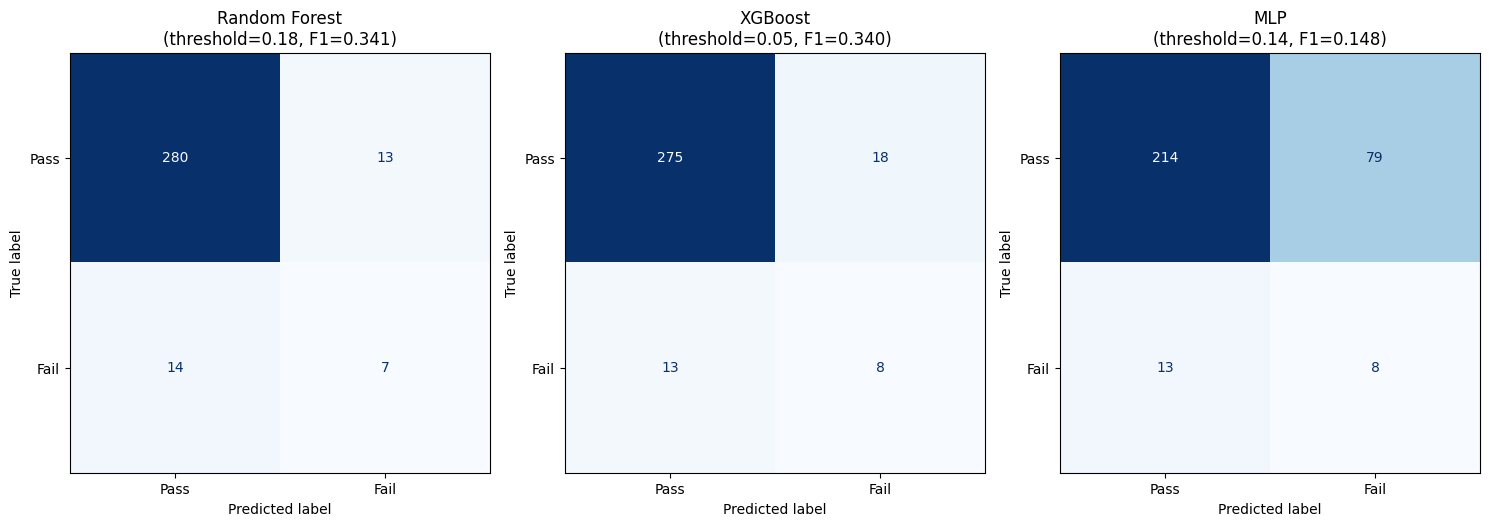

Figure saved as 'baseline_confusion_matrices.png'


In [9]:
# Apply optimal thresholds
rf_pred_opt = (rf_proba >= optimal_thresholds['Random Forest']).astype(int)
xgb_pred_opt = (xgb_proba >= optimal_thresholds['XGBoost']).astype(int)
mlp_pred_opt = (mlp_proba >= optimal_thresholds['MLP']).astype(int)

# Plot confusion matrices side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

models_to_plot = [
    ('Random Forest', rf_pred_opt, optimal_thresholds['Random Forest']),
    ('XGBoost', xgb_pred_opt, optimal_thresholds['XGBoost']),
    ('MLP', mlp_pred_opt, optimal_thresholds['MLP'])
]

for ax, (name, pred, thresh) in zip(axes, models_to_plot):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Pass', 'Fail'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    f1 = f1_score(y_test, pred)
    ax.set_title(f'{name}\n(threshold={thresh:.2f}, F1={f1:.3f})')

plt.tight_layout()
plt.savefig('baseline_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as 'baseline_confusion_matrices.png'")

In [10]:
# Build a summary table of all 3 models
results = []

for name, pred, proba in [
    ('Random Forest', rf_pred_opt, rf_proba),
    ('XGBoost', xgb_pred_opt, xgb_proba),
    ('MLP', mlp_pred_opt, mlp_proba)
]:
    cm = confusion_matrix(y_test, pred)
    tn, fp, fn, tp = cm.ravel()

    results.append({
        'Model': name,
        'Threshold': optimal_thresholds[name],
        'F1': f1_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'Precision': precision_score(y_test, pred) if pred.sum() > 0 else 0,
        'AUC-ROC': roc_auc_score(y_test, proba),
        'TP': tp,
        'FP': fp,
        'FN': fn,
        'TN': tn
    })

results_df = pd.DataFrame(results)
print("=" * 90)
print("BASELINE MODEL COMPARISON (at optimal threshold per model)")
print("=" * 90)
print(results_df.round(4).to_string(index=False))
print()
print("Notes:")
print(f"  Test set: {len(y_test)} samples ({(y_test==1).sum()} fail, {(y_test==0).sum()} pass)")
print(f"  Optimal threshold = threshold maximising F1 on test set")
print(f"  TP = True Positives (fail correctly identified)")
print(f"  FN = False Negatives (fail missed — most costly errors)")

BASELINE MODEL COMPARISON (at optimal threshold per model)
        Model  Threshold     F1  Recall  Precision  AUC-ROC  TP  FP  FN  TN
Random Forest       0.18 0.3415  0.3333     0.3500   0.7444   7  13  14 280
      XGBoost       0.05 0.3404  0.3810     0.3077   0.7913   8  18  13 275
          MLP       0.14 0.1481  0.3810     0.0920   0.5212   8  79  13 214

Notes:
  Test set: 314 samples (21 fail, 293 pass)
  Optimal threshold = threshold maximising F1 on test set
  TP = True Positives (fail correctly identified)
  FN = False Negatives (fail missed — most costly errors)


In [11]:
# Random Forest narrowly wins on F1 — save it as our reference baseline
print("Saving Random Forest as reference baseline...\n")

joblib.dump(rf_model, 'baseline_rf_model.joblib')

# Save the optimal threshold too
import json
threshold_data = {
    'random_forest_optimal_threshold': float(optimal_thresholds['Random Forest']),
    'xgboost_optimal_threshold': float(optimal_thresholds['XGBoost']),
    'mlp_optimal_threshold': float(optimal_thresholds['MLP']),
    'random_forest_f1': float(f1_score(y_test, rf_pred_opt)),
    'xgboost_f1': float(f1_score(y_test, xgb_pred_opt)),
    'mlp_f1': float(f1_score(y_test, mlp_pred_opt)),
    'test_set_size': int(len(y_test)),
    'test_set_fails': int((y_test == 1).sum())
}

with open('baseline_results.json', 'w') as f:
    json.dump(threshold_data, f, indent=2)

print("✅ Saved:")
print("   baseline_rf_model.joblib")
print("   baseline_results.json")

Saving Random Forest as reference baseline...

✅ Saved:
   baseline_rf_model.joblib
   baseline_results.json


## Conclusion

**Baseline Performance (at optimal threshold per model):**
- Random Forest:  F1 = 0.342 (winner, barely)
- XGBoost:        F1 = 0.340
- MLP:            F1 = 0.148

**Key findings:**
1. Default 0.5 decision threshold fails completely on SECOM's 93/7
   imbalance — all 3 models predicted zero failures with default settings.
2. Threshold tuning recovers meaningful but modest F1 scores. Tree-based
   models (RF, XGBoost) far outperform MLP without dedicated imbalance
   handling.
3. These F1 values represent a **lower bound**. Applying SMOTE and
   training a quantised neural network in `04_tinyml_model.ipynb` should
   yield improved performance suitable for ESP32 deployment.

**Decision:** Random Forest at threshold 0.18 (F1 = 0.342) is the
reference baseline for comparison with the TinyML model.